# BEM comparison
1. radial
2. Cp, ct


In [2]:
import os
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Rotor import Rotor
from globals import main_dir,data_dir, plot_dir, res_dir
import plotting_routines
from tqdm import tqdm


In [2]:


R = 0.7

Vinf = 60

const_a_wake_rotor_inputs = dict(
        B=6,
        R=R,
        r_R_H=0.25,
        c_R_func= lambda r_R : 0.18-0.06*r_R,
        twst_func= lambda r_R : -50*r_R+35 ,
        pitch=46,
        polar_path=data_dir.joinpath("ARAD8pct_polar.txt"),
        
        Vinf = np.array([Vinf,0,0]),
        rho = 1.007,
        dist_elem='uniform',
        n_elems_per_wake = 10,
        n_elem = 30,
        periods = 4,
        a_wake=0.2
)
J_lst = np.linspace(1.2,2.7,10)


save_dir = res_dir.joinpath('BEM_comparison')
os.makedirs(save_dir, exist_ok=True)
df = pd.DataFrame([])
for J in tqdm(J_lst):
    n = Vinf/(J*2*R)
    Omega = n*2*np.pi
    rotor = Rotor(**const_a_wake_rotor_inputs,
                Omega=Omega)
    rotor.solve()
    rotor.export_dist(save_dir.joinpath(f'LLM_bem_comparison_J={J:.1f}.csv'))
    summary = rotor.make_summary()
    summary['J'] = J

    df = pd.concat((df,pd.DataFrame([summary])))

df.to_csv(save_dir.joinpath(f'comparison_summary_calibrated.csv'), index=False)




  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:16<02:26, 16.31s/it]

Converged in 47 iterations


 20%|██        | 2/10 [00:20<01:15,  9.46s/it]

Converged in 51 iterations


...

Converged in 39 iterations


 90%|█████████ | 9/10 [00:52<00:04,  4.65s/it]

Converged in 39 iterations


100%|██████████| 10/10 [00:56<00:00,  5.63s/it]

Converged in 33 iterations


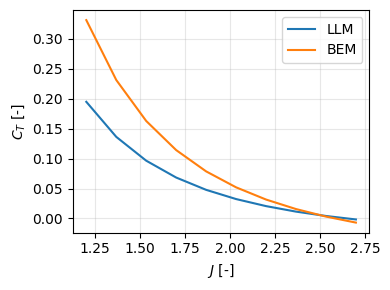

In [9]:
save_dir = res_dir.joinpath('BEM_comparison')

df_llm = pd.read_csv(save_dir.joinpath(f'comparison_summary_calibrated.csv'))
df_bem = pd.read_csv(data_dir.joinpath("results_J_ARAD8.csv"))

fig, ax = plt.subplots(figsize=(4,3))
plotting_routines.forces(plot_vs='J',
                         plot_ag='TC',
                         data_df=df_llm,                
                         ax=ax,
                         label = "LLM")

plotting_routines.forces(plot_vs='J',
                         plot_ag='TC',
                         data_df=df_bem,                
                         ax=ax,
                         label = "BEM")


ax.legend()
fig.tight_layout()
fig.savefig(save_dir.joinpath("CT_vary_J_comparison.pdf"))


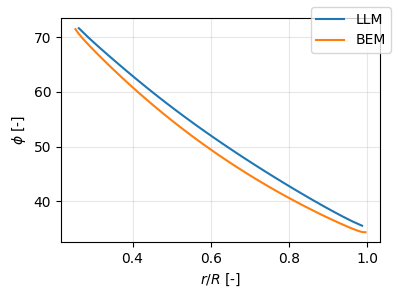

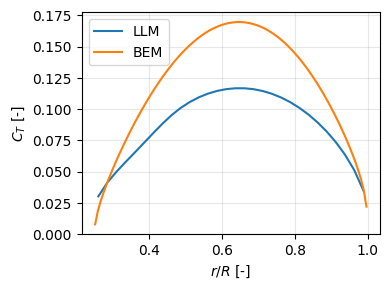

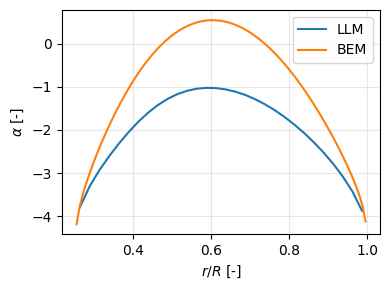

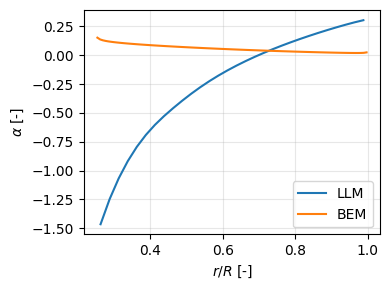

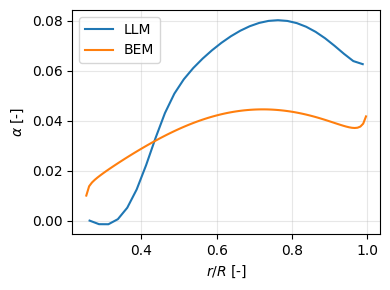

In [ ]:
bem_data = pd.read_csv("results/BEM_span_dist_J_2.0.csv")
llm_data = pd.read_csv("results/BEM_comparison/LLM_bem_comparison_J=2.0.csv")

fig, ax = plt.subplots(figsize=(4,3))
plotting_routines.distribution('phi', llm_data, ax, label=f'LLM')
plotting_routines.distribution('phi', bem_data, ax, label=f'BEM')

ax.set_ylabel(r"$\phi$ [-]")
fig.legend()
fig.tight_layout()
fig.savefig(save_dir.joinpath("radial_phi_comparison_J=2.0.pdf"))

fig, ax = plt.subplots(figsize=(4,3))

plotting_routines.distribution('Ct', llm_data, ax, label=f'LLM',)
plotting_routines.distribution('Ct', bem_data, ax, label=f'BEM',)
ax.set_ylabel(r"$C_T$ [-]")
ax.legend()
fig.tight_layout()
fig.savefig(save_dir.joinpath("radial_CT_comparison_J=2.0.pdf"))


fig, ax = plt.subplots(figsize=(4,3))
plotting_routines.distribution('alpha', llm_data, ax, label=f'LLM')
plotting_routines.distribution('alpha', bem_data, ax, label=f'BEM')

ax.set_ylabel(r"$\alpha$ [-]")
ax.legend()
fig.tight_layout()
fig.savefig(save_dir.joinpath("radial_alpha_comparison_J=2.0.pdf"))

fig, ax = plt.subplots(figsize=(4,3))
plotting_routines.distribution('aline', llm_data, ax, label=f'LLM')
plotting_routines.distribution('aline', bem_data, ax, label=f'BEM')

ax.set_ylabel(r"$a_{line}$ [-]")
ax.legend()
fig.tight_layout()
fig.savefig(save_dir.joinpath("radial_aline_comparison_J=2.0.pdf"))

fig, ax = plt.subplots(figsize=(4,3))
plotting_routines.distribution('a', llm_data, ax, label=f'LLM')
plotting_routines.distribution('a', bem_data, ax, label=f'BEM')

ax.set_ylabel(r"$a$ [-]")
ax.legend()
fig.tight_layout()
fig.savefig(save_dir.joinpath("radial_a_comparison_J=2.0.pdf"))